<a href="https://colab.research.google.com/github/Hamerson-jhoel/TOPICOS-VISION-ARTIFICIAL/blob/main/TALLER2/canales_rgb_raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de canales RGB en imágenes RAW (.dng) bajo distinta iluminación

**Objetivo:** subir 4 fotos `.dng` tomadas con el celular bajo luz **roja**, **verde**, **azul** y **blanca** (brillo máximo), extraer por separado los canales **R, G y B** de cada una y estudiar cómo cambia la intensidad de cada canal según el color de la luz.

**Nota importante sobre la decodificación:** el RAW se decodifica **sin balance de blancos** (`use_camera_wb=False`, `use_auto_wb=False`, `user_wb=[1,1,1,1]`) y **sin brillo automático** (`no_auto_bright=True`). Si el balance de blancos estuviera activo, se intentaría "corregir" el tinte de la luz y las diferencias entre canales que queremos estudiar se atenuarían o desaparecerían.

**Estructura del cuaderno**

| Celda | Contenido |
|---|---|
| 1 | Instalación de librerías e importaciones |
| 2 | Subida de las 4 fotos `.dng` |
| 3 | Etiquetado de cada foto según el color de la luz |
| 4 | Decodificación del RAW y extracción de los canales R, G, B |
| 5 | Guardado de cada canal como imagen individual |
| 6 | Visualización en escala de grises (RGB, R, G, B) |
| 7 | Visualización coloreada (solo para interpretación visual) |
| 8.1 |Corrección de color: rotación óptima entre fotos |
| 8.2 |Corrección de color respecto a la foto original (sin referencia externa)  |
| 9 | Localizar el patrón X-Rite |
| 10 |Calibración de color con el patrón X-Rite|


## Celda 1 · Instalación e importaciones

Se instala `rawpy` (envoltorio de LibRaw, permite leer y decodificar archivos RAW como `.dng`) y se importan las librerías que se usarán en el resto del cuaderno:

- `rawpy`: lectura y decodificación del RAW.
- `numpy` / `pandas`: manejo de arreglos y tablas.
- `matplotlib`: visualización.
- `cv2` (OpenCV): guardado de imágenes PNG de 16 bits.
- `google.colab.files`: subir y descargar archivos en Colab.

In [ ]:
# Instalación silenciosa de rawpy (no viene preinstalado en Colab)
!pip install -q rawpy

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import rawpy
from google.colab import files

print("rawpy versión:", rawpy.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 23.3 MB/s eta 0:00:00
rawpy versión: 0.27.1


## Celda 2 · Subir las 4 fotos `.dng`

Se abre el selector de archivos de Colab para subir las cuatro fotos RAW. Cada archivo se guarda en la carpeta `fotos_dng/` y luego se listan solo los que tienen extensión `.dng`.

**Recomendaciones al tomar las fotos**
- Usar el modo manual/Pro de la cámara y **fijar ISO, tiempo de exposición y enfoque**. Si el celular ajusta la exposición automáticamente, compensa parte de la diferencia de brillo entre las luces y contamina la comparación.
- Mantener la misma escena y la misma posición del celular en las cuatro tomas.
- Renombrar los archivos con el color de la luz (por ejemplo `roja.dng`, `verde.dng`, `azul.dng`, `blanca.dng`) facilita la celda 3.

In [ ]:
CARPETA_FOTOS = "fotos_dng"
os.makedirs(CARPETA_FOTOS, exist_ok=True)

# Abre el selector de archivos; devuelve un diccionario {nombre: bytes}
subidos = files.upload()

# Guardar cada archivo subido dentro de la carpeta de trabajo
for nombre, contenido in subidos.items():
    with open(os.path.join(CARPETA_FOTOS, nombre), "wb") as f:
        f.write(contenido)

# Quedarse solo con los .dng (sin importar mayúsculas/minúsculas)
archivos = sorted(
    os.path.join(CARPETA_FOTOS, n)
    for n in os.listdir(CARPETA_FOTOS)
    if n.lower().endswith(".dng")
)

print(f"Archivos .dng encontrados: {len(archivos)}")
for a in archivos:
    print("  -", a)

if len(archivos) != 4:
    print("\n⚠️ Se esperaban exactamente 4 fotos .dng. Revisa los archivos subidos.")

Saving azul.dng to azul.dng
Saving rojo.dng to rojo.dng
Saving verde.dng to verde.dng
Saving brillomax.dng to brillomax.dng
Archivos .dng encontrados: 4
  - fotos_dng/azul.dng
  - fotos_dng/brillomax.dng
  - fotos_dng/rojo.dng
  - fotos_dng/verde.dng


## Celda 3 · Etiquetar cada foto según el color de la luz

Se detecta **automáticamente** el color de la luz a partir de palabras clave en el nombre del archivo (por ejemplo `roja`, `red`, `verde`, `green`, `azul`, `blue`, `blanca`, `white`, `brillo`).

El resultado se guarda en el diccionario `ETIQUETAS` con la forma `{"roja": ruta, ...}` y se imprime al final de la celda. **Si alguna foto no se reconoce**, ajusta manualmente el diccionario `ETIQUETAS` (hay un ejemplo comentado en el código).

In [ ]:
# Orden fijo en el que se procesarán y mostrarán las fotos
ORDEN = ["roja", "verde", "azul", "blanca"]

# Palabras clave (en minúsculas) que identifican cada condición de luz
PALABRAS_CLAVE = {
    "roja":   ["roja", "rojo", "red"],
    "verde":  ["verde", "green"],
    "azul":   ["azul", "blue"],
    "blanca": ["blanca", "blanco", "white", "brillo", "max"],
}

# Detección automática: se asigna cada archivo a la primera etiqueta que coincida
ETIQUETAS = {}
for ruta in archivos:
    nombre = os.path.basename(ruta).lower()
    for etiqueta, palabras in PALABRAS_CLAVE.items():
        if any(p in nombre for p in palabras):
            ETIQUETAS[etiqueta] = ruta
            break

# --- AJUSTE MANUAL (descomentar y editar si la detección automática falla) ---
# ETIQUETAS = {
#     "roja":   "fotos_dng/IMG_0001.dng",
#     "verde":  "fotos_dng/IMG_0002.dng",
#     "azul":   "fotos_dng/IMG_0003.dng",
#     "blanca": "fotos_dng/IMG_0004.dng",
# }

print("ETIQUETAS =")
for etiqueta in ORDEN:
    print(f"  {etiqueta:7s} -> {ETIQUETAS.get(etiqueta, '❌ NO RECONOCIDA')}")

faltan = [e for e in ORDEN if e not in ETIQUETAS]
if faltan:
    raise ValueError(f"Faltan etiquetas por asignar: {faltan}. Ajusta el diccionario ETIQUETAS.")

ETIQUETAS =
  roja    -> fotos_dng/rojo.dng
  verde   -> fotos_dng/verde.dng
  azul    -> fotos_dng/azul.dng
  blanca  -> fotos_dng/brillomax.dng


## Celda 4 · Decodificar el RAW y extraer los canales R, G, B

Se decodifica cada `.dng` con `raw.postprocess(...)` usando parámetros que **evitan cualquier corrección de color o brillo**, ya que el objetivo es observar los datos tal como los captó el sensor:

| Parámetro | Valor | Motivo |
|---|---|---|
| `use_camera_wb` | `False` | No aplicar el balance de blancos guardado por el celular |
| `use_auto_wb` | `False` | No estimar un balance de blancos automático |
| `user_wb` | `[1, 1, 1, 1]` | Multiplicadores neutros. Sin esto, LibRaw aplicaría por defecto multiplicadores de "luz de día" |
| `no_auto_bright` | `True` | No reescalar el brillo automáticamente |
| `gamma` | `(1, 1)` | Mantener valores **lineales** (sin curva gamma), para que la intensidad sea proporcional a la luz captada |
| `output_bps` | `16` | Salida de 16 bits (valores de 0 a 65535), sin perder información |
| `output_color` | `raw` | No convertir al espacio de color sRGB |

Después se separan los tres canales de cada imagen y se guardan en el diccionario `CANALES`.

In [ ]:
MAXVAL = 65535  # valor máximo con 16 bits por canal

IMAGENES = {}   # {etiqueta: imagen RGB completa (alto x ancho x 3)}
CANALES = {}    # {etiqueta: {"R": matriz, "G": matriz, "B": matriz}}

for etiqueta in ORDEN:
    with rawpy.imread(ETIQUETAS[etiqueta]) as raw:
        rgb = raw.postprocess(
            use_camera_wb=False,                    # sin balance de blancos de la cámara
            use_auto_wb=False,                      # sin balance de blancos automático
            user_wb=[1, 1, 1, 1],                   # multiplicadores neutros (R, G, B, G2)
            no_auto_bright=True,                    # sin brillo automático
            gamma=(1, 1),                           # respuesta lineal (sin gamma)
            output_bps=16,                          # 16 bits por canal
            output_color=rawpy.ColorSpace.raw,      # sin conversión a sRGB
        )

    IMAGENES[etiqueta] = rgb
    # Canal 0 = R, canal 1 = G, canal 2 = B (cada uno es una matriz 2D en escala de grises)
    CANALES[etiqueta] = {"R": rgb[:, :, 0], "G": rgb[:, :, 1], "B": rgb[:, :, 2]}

    print(f"{etiqueta:7s} | forma: {rgb.shape} | tipo: {rgb.dtype} | "
          f"mín: {rgb.min()} | máx: {rgb.max()}")

roja    | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535
verde   | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535
azul    | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535
blanca  | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535


## Celda 5 · Guardar cada componente como imagen individual

Cada canal se guarda como un **PNG en escala de grises de 16 bits** dentro de la carpeta `canales_guardados/`, con nombres del tipo `roja_R.png`, `roja_G.png`, `roja_B.png`, etc. (12 archivos en total).

Al guardar en 16 bits se conserva toda la información original: el valor de cada píxel es directamente la intensidad de ese canal (0 = negro, 65535 = blanco), sin ningún color agregado.

Al final hay una línea comentada para descargar todo en un `.zip`.

In [ ]:
SALIDA = "canales_guardados"
os.makedirs(SALIDA, exist_ok=True)

for etiqueta in ORDEN:
    for canal, matriz in CANALES[etiqueta].items():
        ruta_png = os.path.join(SALIDA, f"{etiqueta}_{canal}.png")
        # OpenCV guarda uint16 como PNG de 16 bits sin pérdida
        cv2.imwrite(ruta_png, matriz)

print("Archivos guardados:")
for n in sorted(os.listdir(SALIDA)):
    print("  -", n)

# Para descargar todos los canales en un solo .zip, descomentar estas dos líneas:
# shutil.make_archive("canales_guardados", "zip", SALIDA)
# files.download("canales_guardados.zip")

Archivos guardados:
  - azul_B.png
  - azul_G.png
  - azul_R.png
  - blanca_B.png
  - blanca_G.png
  - blanca_R.png
  - roja_B.png
  - roja_G.png
  - roja_R.png
  - verde_B.png
  - verde_G.png
  - verde_R.png


## Celda 6 · Ver los 3 canales de cada foto en escala de grises

Cada **fila** es una foto (una condición de luz) y las **columnas** son: RGB completo, canal R, canal G y canal B.

Los 3 canales se muestran en escala de grises (`cmap="gray"`), igual que se guardaron en la celda 5: el brillo de cada píxel es directamente el valor de intensidad de ese canal (0 = negro, 65535 = blanco), **sin ningún color agregado**.

**Detalles importantes para que la comparación sea justa**
- Se fijan `vmin=0` y `vmax=1` (valores normalizados) en **todas** las imágenes. Si no se hiciera, `imshow` reescalaría cada panel a su propio mínimo y máximo, y un canal débil se vería igual de brillante que uno fuerte.
- Para no saturar la memoria de Colab, solo se muestra 1 de cada `PASO` píxeles (submuestreo) y solo para visualizar. Los cálculos y los archivos guardados usan la resolución completa.
- Como los datos son lineales, las imágenes pueden verse oscuras. Si quieres aclararlas **igual en todos los paneles**, sube `GAMMA_VISUAL` a `2.2`. Es solo un ajuste visual.

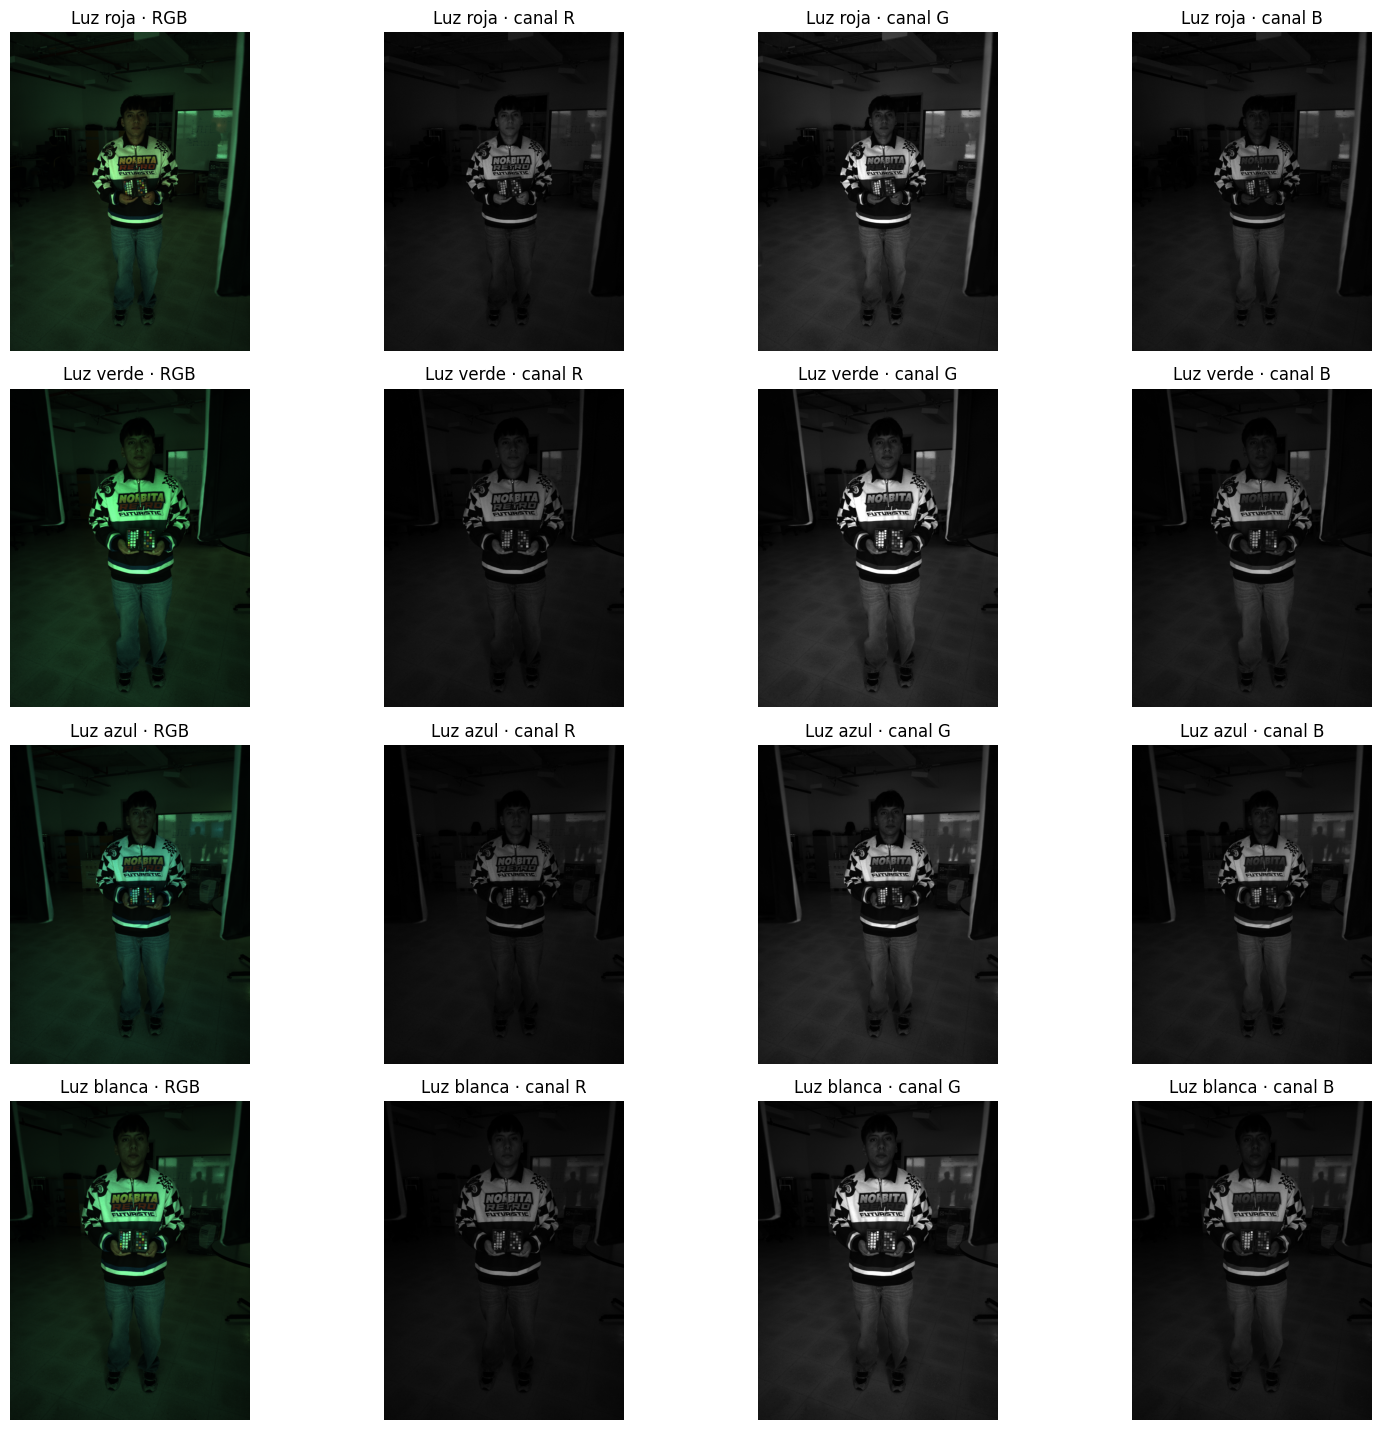

In [ ]:
PASO = 4             # submuestreo solo para mostrar (1 de cada 4 píxeles)
GAMMA_VISUAL = 1.0   # 1.0 = lineal (fiel a los datos); 2.2 = aclara solo para ver

def preparar(matriz):
    # Normaliza a [0, 1] y submuestrea; la escala es idéntica para todas las imágenes
    x = matriz[::PASO, ::PASO].astype(np.float32) / MAXVAL
    return np.clip(x, 0, 1) ** (1 / GAMMA_VISUAL)

fig, ejes = plt.subplots(len(ORDEN), 4, figsize=(16, 3.6 * len(ORDEN)))

for i, etiqueta in enumerate(ORDEN):
    # Columna 0: imagen RGB completa
    ejes[i, 0].imshow(preparar(IMAGENES[etiqueta]))
    ejes[i, 0].set_title(f"Luz {etiqueta} · RGB")

    # Columnas 1-3: cada canal en escala de grises con escala fija (vmin/vmax)
    for j, canal in enumerate(["R", "G", "B"], start=1):
        ejes[i, j].imshow(preparar(CANALES[etiqueta][canal]), cmap="gray", vmin=0, vmax=1)
        ejes[i, j].set_title(f"Luz {etiqueta} · canal {canal}")

for ax in ejes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

## Celda 7 · Vista coloreada (solo para interpretar más fácil en pantalla)

Esta celda es **puramente visual**: colorea cada canal con su color correspondiente (R en rojo, G en verde, B en azul) para que sea más intuitivo comparar a simple vista cuál canal domina en cada foto.

**No cambia ni reemplaza** los archivos en escala de grises guardados en la celda 5: es solo otra forma de mirar los mismos datos. Se mantiene la misma escala fija que en la celda 6.

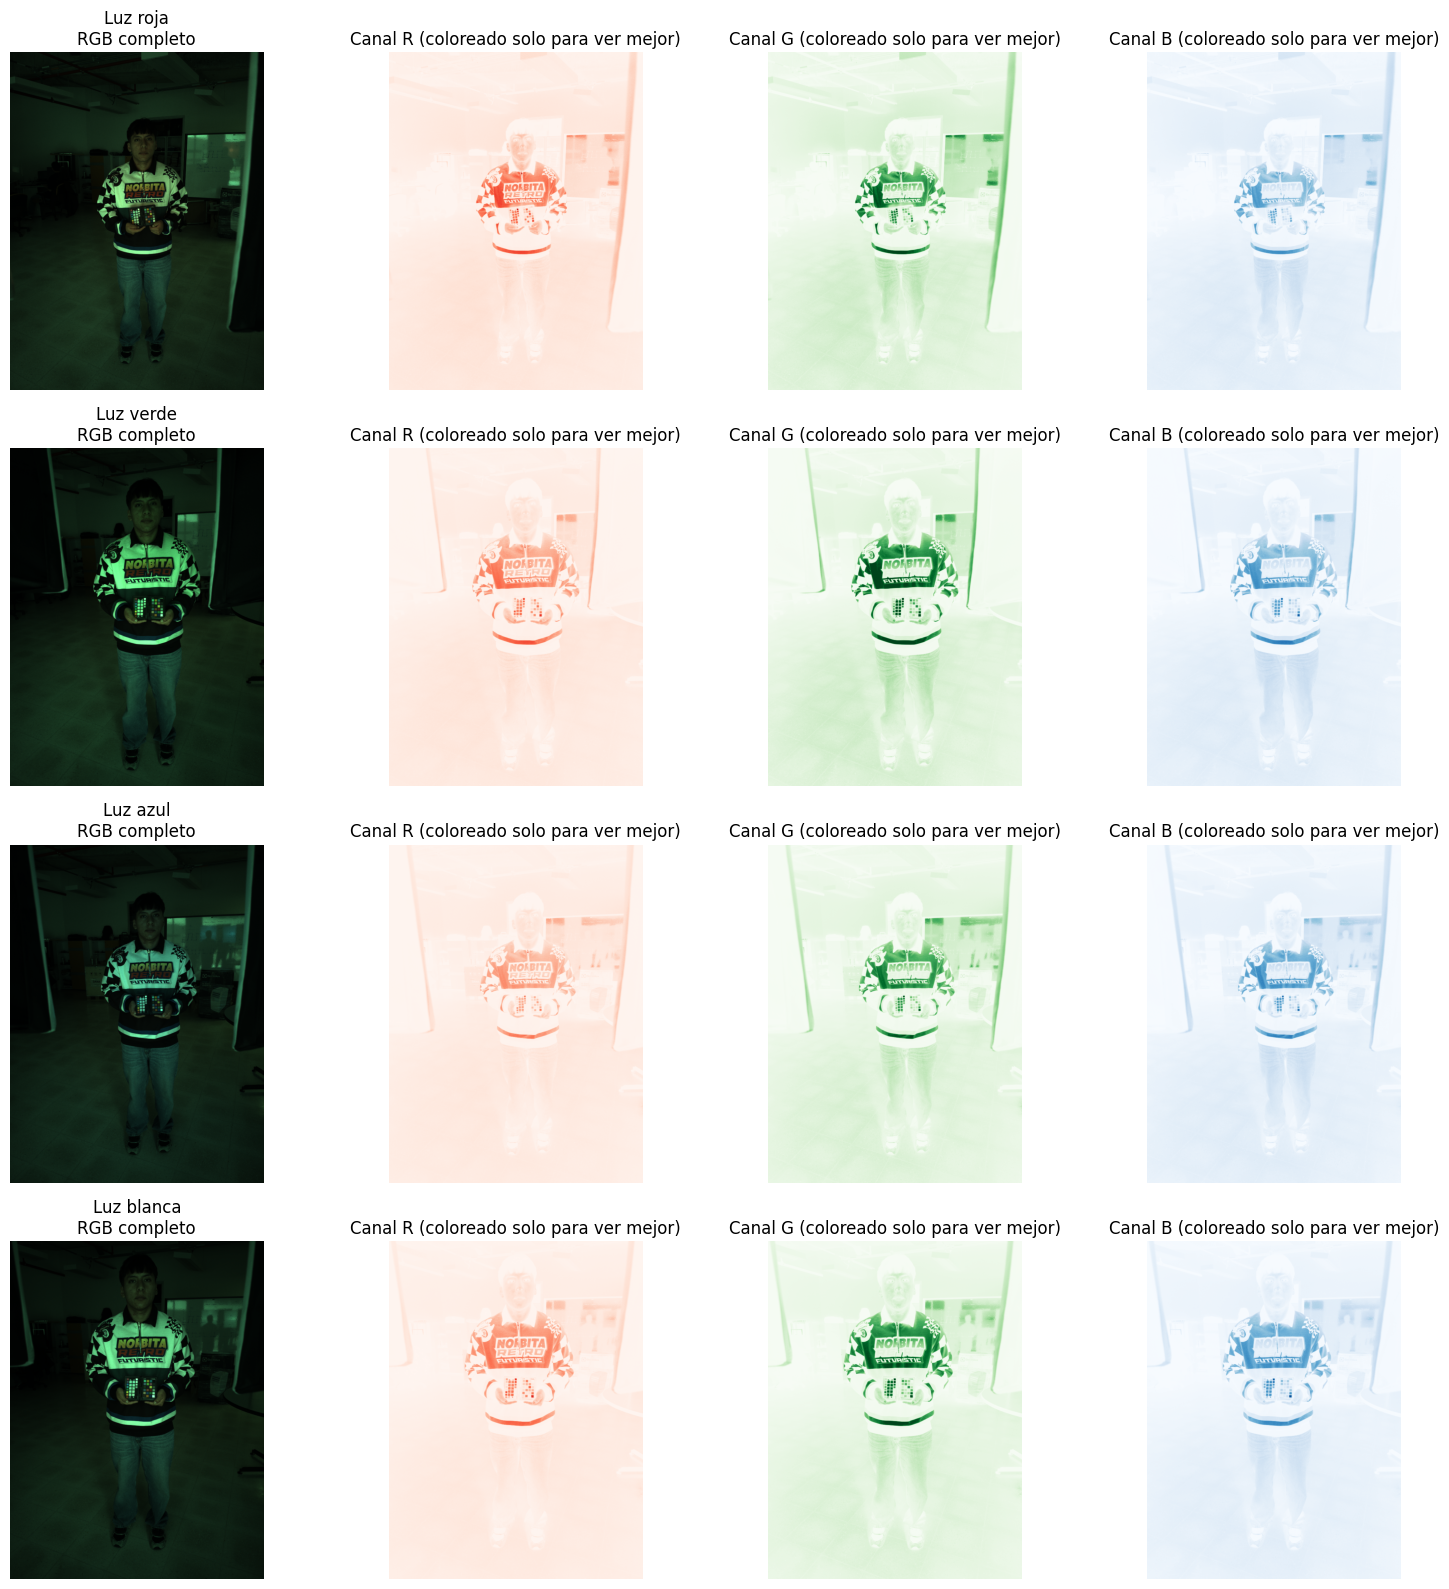

In [ ]:
n = len(ORDEN)   # número de fotos (filas de la figura)

fig, axs = plt.subplots(n, 4, figsize=(16, 4 * n))
if n == 1:
    axs = axs[None, :]   # garantiza que axs siempre sea 2D, aunque haya una sola foto

# Mapa de color de cada canal (solo para ver mejor en pantalla)
CMAPS = {"R": "Reds", "G": "Greens", "B": "Blues"}

for i, etiqueta in enumerate(ORDEN):
    # Columna 0: imagen RGB completa
    axs[i, 0].imshow(preparar(IMAGENES[etiqueta]))
    axs[i, 0].set_title(f"Luz {etiqueta}\nRGB completo")
    axs[i, 0].axis("off")

    # Columnas 1-3: cada canal con su mapa de color y escala fija (vmin/vmax)
    for j, canal in enumerate(["R", "G", "B"], start=1):
        axs[i, j].imshow(preparar(CANALES[etiqueta][canal]),
                         cmap=CMAPS[canal], vmin=0, vmax=1)
        axs[i, j].set_title(f"Canal {canal} (coloreado solo para ver mejor)")
        axs[i, j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(SALIDA, "comparacion_canales_coloreada.png"), dpi=120, bbox_inches="tight")
plt.show()

## Celda 8.1 Corrección de color: rotación óptima entre fotos

Se busca la **rotación en el espacio RGB** que hace que los colores de cada foto (luz roja, verde y azul) cuadren con los de la foto de referencia (luz blanca). Cada píxel se trata como un vector (R, G, B) y se resuelve el **problema de Procrustes ortogonal** mediante SVD: se encuentra la matriz de rotación `R` (ortogonal, con determinante +1) y un factor de escala `s` que minimizan el error entre `s·(píxeles origen)·R` y los píxeles de la foto destino.

Se reporta, para cada foto: la matriz de rotación, el ángulo total de rotación, la escala, y el error (RMSE) **antes y después** de la corrección. Como comparación, también se muestra el error con una matriz 3×3 general (mínimos cuadrados).

**Requisito:** las fotos deben estar alineadas (misma escena y misma posición del celular), porque se comparan píxel a píxel.


=== roja -> azul ===
Matriz de rotación R:
 [[ 0.6434 -0.2336  0.729 ]
 [ 0.4626  0.8774 -0.127 ]
 [-0.61    0.4189  0.6726]]

=== verde -> azul ===
Matriz de rotación R:
 [[ 0.9618  0.1809 -0.2055]
 [-0.1393  0.9695  0.2019]
 [ 0.2358 -0.1655  0.9576]]

=== blanca -> azul ===
Matriz de rotación R:
 [[ 0.8858 -0.2055  0.4162]
 [ 0.2668  0.9591 -0.0943]
 [-0.3798  0.1946  0.9044]]


,Ángulo (°),Escala s,RMSE antes,RMSE rotación,RMSE 3x3 general
Foto,,,,,
roja,53.3658,0.6134,0.1081,0.0931,0.0925
verde,19.1915,0.6181,0.1046,0.0881,0.0878
blanca,28.9992,0.5665,0.1153,0.0980,0.0978


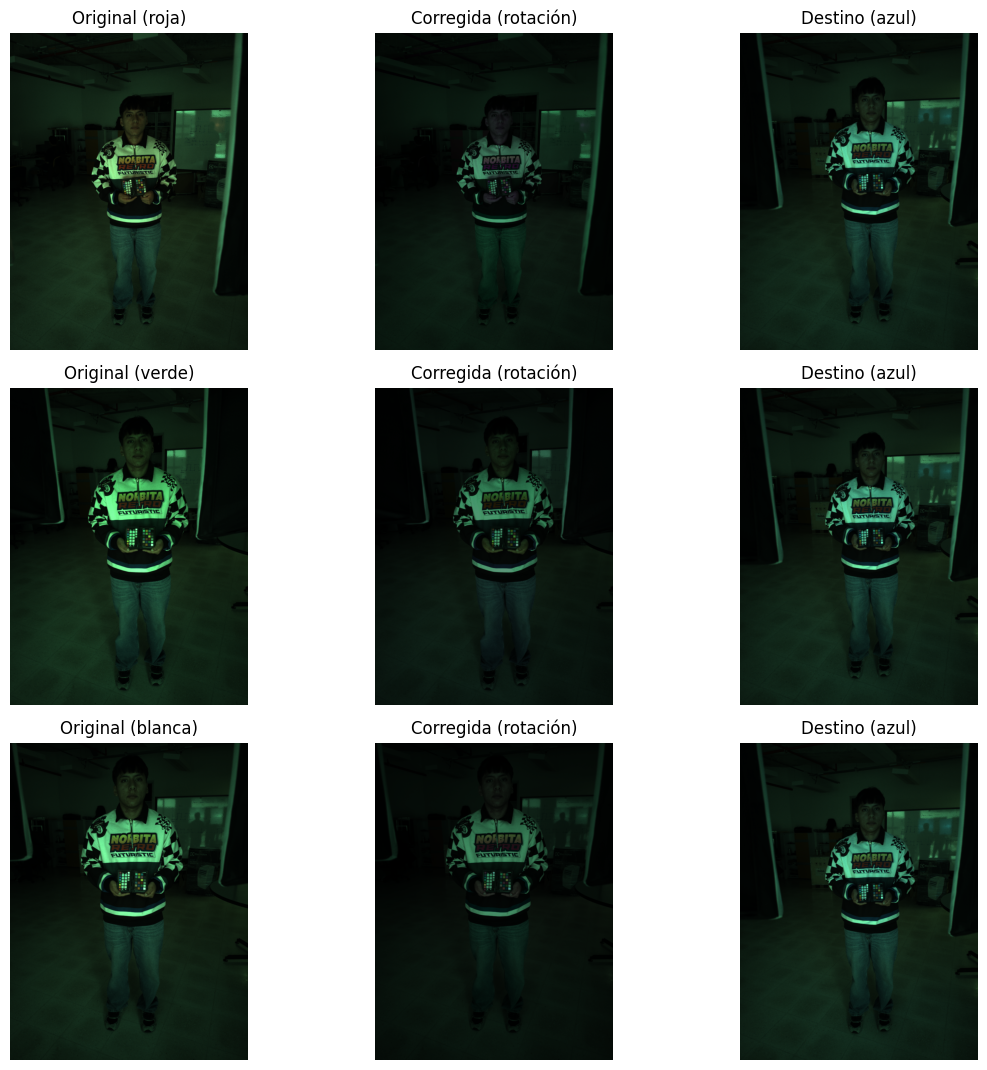

In [ ]:
REFERENCIA = "azul"        # foto destino: hacia donde se quiere "rotar" los colores, elegible entre roja, verde, azul y blanca
PASO_COLOR = 8               # submuestreo para el ajuste (suficiente y liviano en memoria)

def pixeles(etiqueta):
    # Convierte la imagen en una matriz N x 3 (un píxel por fila), normalizada a [0, 1]
    img = IMAGENES[etiqueta][::PASO_COLOR, ::PASO_COLOR]
    return img.reshape(-1, 3).astype(np.float64) / MAXVAL

B = pixeles(REFERENCIA)      # píxeles destino
ROTACIONES = {}
filas = []

for etiqueta in [e for e in ORDEN if e != REFERENCIA]:
    A = pixeles(etiqueta)    # píxeles origen
    assert A.shape == B.shape, "Las fotos deben tener la misma resolución y estar alineadas"

    # --- Procrustes ortogonal: minimiza ||s * A @ R - B|| con R ortogonal ---
    U, S, Vt = np.linalg.svd(A.T @ B)               # SVD de la matriz de correlación
    d = np.sign(np.linalg.det(U @ Vt))              # d = -1 sería una reflexión, no una rotación
    D = np.diag([1, 1, d])
    R = U @ D @ Vt                                   # rotación óptima (det = +1)
    s = (S * np.diag(D)).sum() / (A ** 2).sum()      # escala óptima

    # Ángulo total de la rotación (a partir de la traza de R)
    angulo = np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1)))

    # Errores (RMSE) antes y después de la corrección
    rmse_antes = np.sqrt(np.mean((A - B) ** 2))
    rmse_rot   = np.sqrt(np.mean((s * A @ R - B) ** 2))

    # Comparación: matriz 3x3 general por mínimos cuadrados (sin restricción de rotación)
    M, *_ = np.linalg.lstsq(A, B, rcond=None)
    rmse_gen = np.sqrt(np.mean((A @ M - B) ** 2))

    ROTACIONES[etiqueta] = {"R": R, "s": s}
    filas.append({"Foto": etiqueta, "Ángulo (°)": angulo, "Escala s": s,
                  "RMSE antes": rmse_antes, "RMSE rotación": rmse_rot,
                  "RMSE 3x3 general": rmse_gen})

    print(f"\n=== {etiqueta} -> {REFERENCIA} ===")
    print("Matriz de rotación R:\n", np.round(R, 4))

display(pd.DataFrame(filas).set_index("Foto").round(4))

# --- Comparación visual: origen | origen corregido | destino ---
fig, axs = plt.subplots(len(ROTACIONES), 3, figsize=(12, 3.6 * len(ROTACIONES)))
axs = np.atleast_2d(axs)

for i, (etiqueta, p) in enumerate(ROTACIONES.items()):
    img = IMAGENES[etiqueta][::PASO, ::PASO].astype(np.float64) / MAXVAL
    corregida = np.clip(p["s"] * img.reshape(-1, 3) @ p["R"], 0, 1).reshape(img.shape)
    destino = IMAGENES[REFERENCIA][::PASO, ::PASO].astype(np.float64) / MAXVAL

    for ax, im, titulo in zip(axs[i], [img, corregida, destino],
                              [f"Original ({etiqueta})", "Corregida (rotación)", f"Destino ({REFERENCIA})"]):
        ax.imshow(np.clip(im, 0, 1)); ax.set_title(titulo); ax.axis("off")

plt.tight_layout()
plt.show()

## Celda 8.2 Corrección de color respecto a la foto original (sin referencia externa)

Esta celda calcula qué transformación de color separa cada foto **sin corregir** (la decodificada en la celda 4) de su versión **original**, es decir, la que entrega el celular con su propio balance de blancos. Así, cada foto se compara consigo misma y no se necesita otra foto como referencia.

**Qué hace, paso a paso**

1. **Decodifica de nuevo cada `.dng`** con `use_camera_wb=True`, para obtener la versión "original" con el balance de blancos de la cámara. Se mantienen `gamma=(1, 1)` y `output_bps=16` para que ambas versiones sean lineales y comparables.
2. **Convierte cada imagen en una matriz de píxeles** de tamaño N × 3 (un vector R, G, B por fila), normalizada entre 0 y 1 y submuestreada para que el ajuste sea liviano en memoria.
3. **Calcula la rotación óptima en el espacio de color RGB** mediante el problema de Procrustes ortogonal, usando la descomposición en valores singulares (SVD). Se obtiene una matriz de rotación `R` (ortogonal, con determinante +1) y una escala `s` tales que `s · (píxeles sin corregir) · R` quede lo más cerca posible de los píxeles originales.
4. **Calcula el ángulo total de rotación** a partir de la traza de `R`: `ángulo = arccos((traza(R) − 1) / 2)`.
5. **Calcula, como comparación, otras dos correcciones:**
   - *Ganancias por canal* (una multiplicación independiente para R, G y B), que es lo que hace un balance de blancos clásico.
   - *Matriz 3×3 general* por mínimos cuadrados, sin la restricción de ser una rotación.
6. **Mide el error (RMSE)** antes de corregir y después de cada corrección, y los presenta en una tabla junto con el ángulo, la escala y las ganancias.
7. **Muestra tres columnas por foto:** sin corregir, corregida mediante la rotación y original (cámara).

**Cómo interpretar los resultados**

- El **ángulo** indica cuánto hay que "girar" los colores para acercarse a la versión original.
- Si el **RMSE con rotación** es menor que el de **antes**, la rotación ayuda a acercar los colores.
- Es probable que las **ganancias por canal** y la **matriz 3×3** logren un error menor que la rotación pura, porque un balance de blancos actúa como un factor distinto en cada canal y no como un giro. Esto es un resultado esperable y no un error.
- Las columnas `Gan. R / G / B` muestran cuánto amplifica o atenúa la cámara cada canal en cada condición de luz.

**Requisito:** las dos versiones de cada foto provienen del mismo archivo `.dng`, por lo que están perfectamente alineadas píxel a píxel.


=== roja: sin corrección -> original ===
Matriz de rotación R:
 [[ 0.9829 -0.18   -0.0379]
 [ 0.1839  0.9679  0.1711]
 [ 0.0059 -0.1752  0.9845]]

=== verde: sin corrección -> original ===
Matriz de rotación R:
 [[ 9.729e-01 -2.281e-01 -3.680e-02]
 [ 2.311e-01  9.601e-01  1.575e-01]
 [-6.000e-04 -1.617e-01  9.868e-01]]

=== azul: sin corrección -> original ===
Matriz de rotación R:
 [[ 0.9683 -0.2493  0.0153]
 [ 0.2452  0.9607  0.1303]
 [-0.0471 -0.1224  0.9914]]

=== blanca: sin corrección -> original ===
Matriz de rotación R:
 [[ 0.9742 -0.2248 -0.0209]
 [ 0.2254  0.9634  0.1451]
 [-0.0125 -0.1461  0.9892]]


,Ángulo (°),Escala s,Gan. R,Gan. G,Gan. B,RMSE antes,RMSE rotación,RMSE ganancias,RMSE 3x3
Foto,,,,,,,,,
roja,14.6021,1.3339,1.7815,1.0009,1.6249,0.0644,0.0197,0.0149,0.0073
verde,16.2716,1.3390,2.0137,1.0145,1.6391,0.0710,0.0199,0.0152,0.0099
azul,16.2249,1.3141,1.9153,0.9951,1.5515,0.0562,0.0151,0.0116,0.0062
blanca,15.5522,1.3286,1.9159,1.0054,1.5899,0.0651,0.0179,0.0134,0.0073


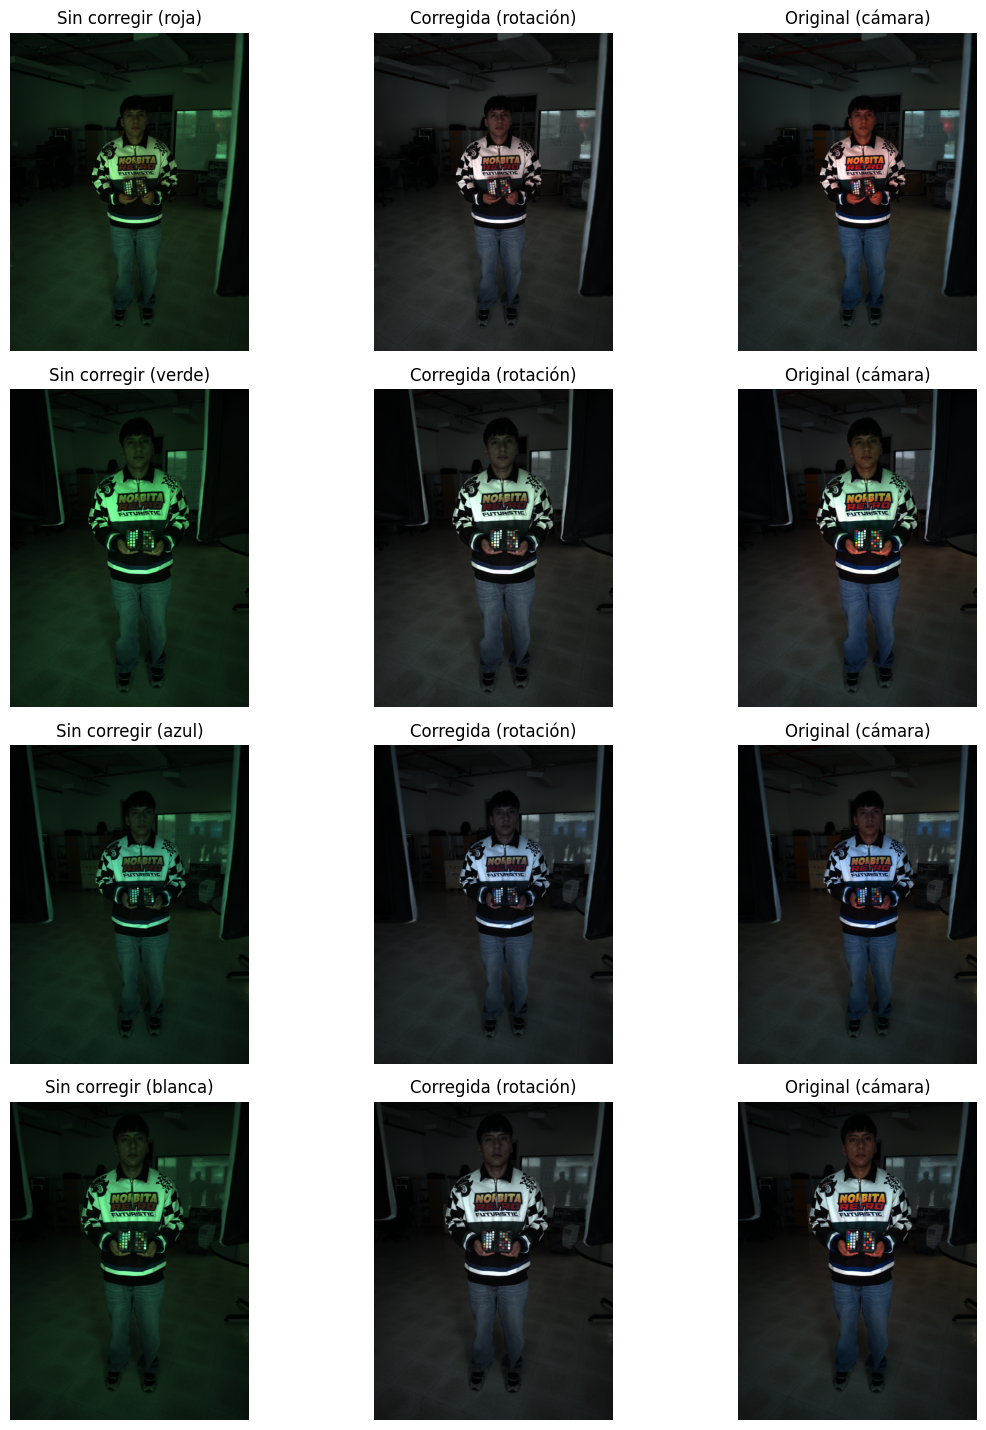

In [ ]:
ROTACIONES = {}
filas = []

for etiqueta in ORDEN:
    # Versión "original": decodificada con el balance de blancos de la cámara
    with rawpy.imread(ETIQUETAS[etiqueta]) as raw:
        original = raw.postprocess(
            use_camera_wb=True,        # aplica el balance de blancos del celular
            no_auto_bright=True,       # sin reescalado de brillo
            gamma=(1, 1),              # lineal, para comparar con la celda 4
            output_bps=16,
        )

    A = pixeles(etiqueta)                                                    # sin corrección (celda 4)
    B = original[::PASO_COLOR, ::PASO_COLOR].reshape(-1, 3).astype(np.float64) / MAXVAL

    # --- Procrustes ortogonal con escala: s * A @ R ≈ B ---
    U, S, Vt = np.linalg.svd(A.T @ B)
    d = np.sign(np.linalg.det(U @ Vt))      # asegura rotación (det = +1), no reflexión
    D = np.diag([1, 1, d])
    R = U @ D @ Vt
    s = (S * np.diag(D)).sum() / (A ** 2).sum()
    angulo = np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1)))

    # Ganancias por canal (lo que hace un balance de blancos clásico)
    ganancias = (A * B).sum(axis=0) / (A ** 2).sum(axis=0)

    # Matriz 3x3 general, solo como comparación
    M, *_ = np.linalg.lstsq(A, B, rcond=None)

    ROTACIONES[etiqueta] = {"R": R, "s": s, "original": original}
    filas.append({
        "Foto": etiqueta, "Ángulo (°)": angulo, "Escala s": s,
        "Gan. R": ganancias[0], "Gan. G": ganancias[1], "Gan. B": ganancias[2],
        "RMSE antes": np.sqrt(np.mean((A - B) ** 2)),
        "RMSE rotación": np.sqrt(np.mean((s * A @ R - B) ** 2)),
        "RMSE ganancias": np.sqrt(np.mean((A * ganancias - B) ** 2)),
        "RMSE 3x3": np.sqrt(np.mean((A @ M - B) ** 2)),
    })
    print(f"\n=== {etiqueta}: sin corrección -> original ===")
    print("Matriz de rotación R:\n", np.round(R, 4))

display(pd.DataFrame(filas).set_index("Foto").round(4))

# --- Visual: sin corregir | corregida por rotación | original (cámara) ---
fig, axs = plt.subplots(len(ORDEN), 3, figsize=(12, 3.6 * len(ORDEN)))
for i, etiqueta in enumerate(ORDEN):
    p = ROTACIONES[etiqueta]
    img = IMAGENES[etiqueta][::PASO, ::PASO].astype(np.float64) / MAXVAL
    corregida = np.clip(p["s"] * img.reshape(-1, 3) @ p["R"], 0, 1).reshape(img.shape)
    orig = np.clip(p["original"][::PASO, ::PASO].astype(np.float64) / MAXVAL, 0, 1)
    for ax, im, t in zip(axs[i], [img, corregida, orig],
                         [f"Sin corregir ({etiqueta})", "Corregida (rotación)", "Original (cámara)"]):
        ax.imshow(np.clip(im, 0, 1)); ax.set_title(t); ax.axis("off")
plt.tight_layout()
plt.show()

## Celda 9 · Localizar el patrón X-Rite

Se decodifica la foto que contiene el patrón (RAW lineal, sin balance de blancos ni gamma) y se muestran dos vistas con ejes en píxeles de la imagen completa: la foto entera, con un rectángulo que marca la zona ampliada, y un **zoom al patrón**. Desde el zoom se leen las coordenadas (x, y) del centro de 4 parches de referencia, que se usan en la celda 10. Se identifican por su **color**, no por su posición en la foto: P1 (marrón oscuro), P6 (verde azulado), P24 (negro) y P19 (blanco).

Se usa el panel del ColorChecker Passport con los 24 parches del modelo Classic. Las vistas están aclaradas y balanceadas por canal solo para poder verlas; los datos usados después son los lineales sin modificar.

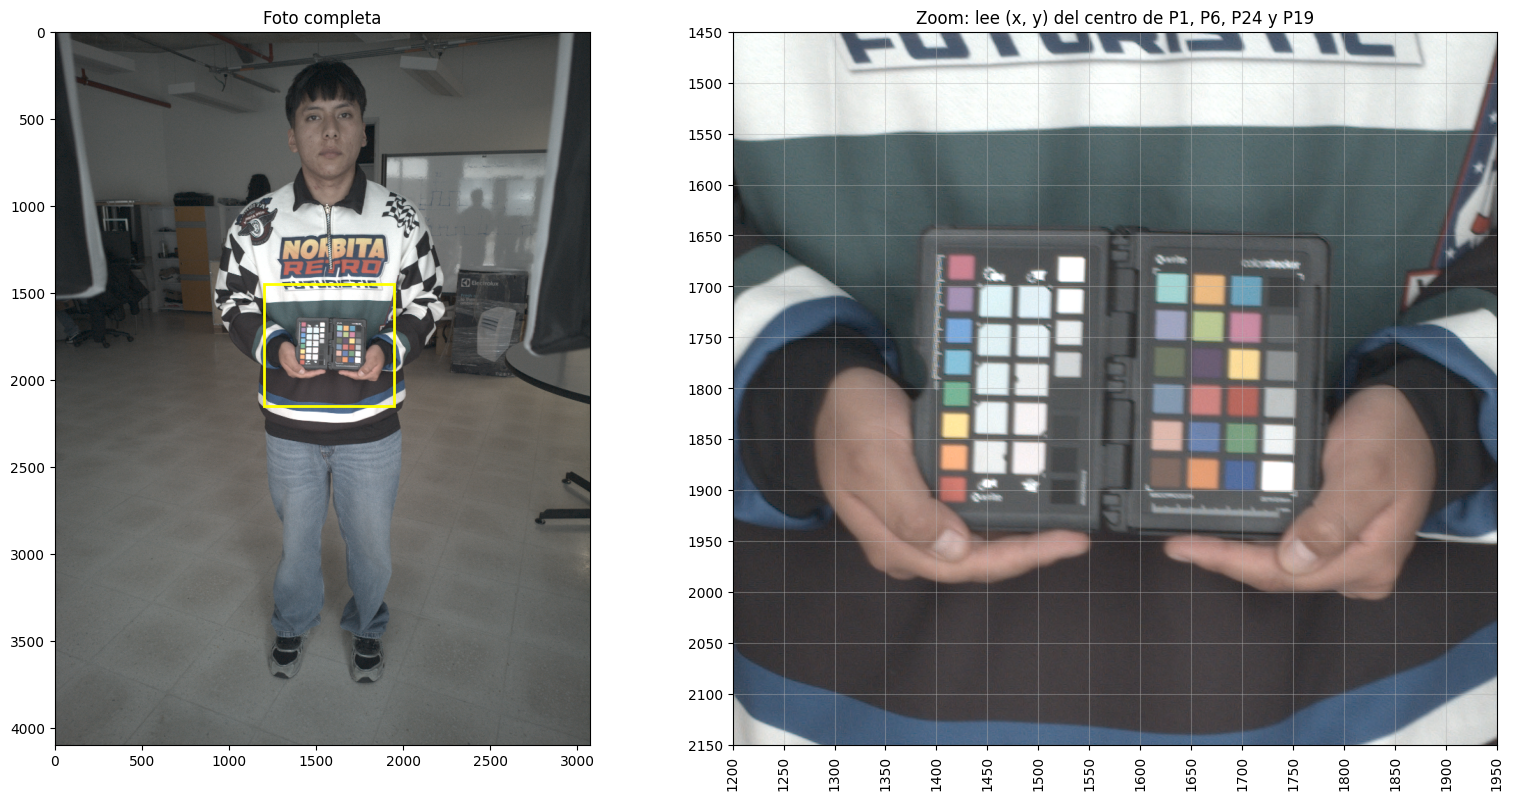

In [ ]:
RUTA_PATRON = ETIQUETAS["blanca"]    # .dng que contiene el patrón X-Rite
ZOOM = (1200, 1950, 1450, 2150)      # (X0, X1, Y0, Y1) recorte alrededor del patrón; amplía si queda cortado

# Decodificación lineal, sin balance de blancos ni brillo automático (igual que en la celda 4)
with rawpy.imread(RUTA_PATRON) as raw:
    patron = raw.postprocess(
        use_camera_wb=False, use_auto_wb=False, user_wb=[1, 1, 1, 1],
        no_auto_bright=True, gamma=(1, 1), output_bps=16,
        output_color=rawpy.ColorSpace.raw,
    )
alto, ancho = patron.shape[:2]

def aclarar(x):
    # Solo para VER: normaliza cada canal por separado y aplica gamma (reduce el tinte verde)
    x = x.astype(np.float32) / MAXVAL
    return np.clip(x / np.percentile(x, 99.5, axis=(0, 1)), 0, 1) ** (1 / 2.2)

X0, X1, Y0, Y1 = ZOOM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1, 1.3]})

# Izquierda: foto completa con el recuadro del zoom
ax1.imshow(aclarar(patron[::PASO, ::PASO]), extent=[0, ancho, alto, 0])
ax1.add_patch(plt.Rectangle((X0, Y0), X1 - X0, Y1 - Y0, fill=False, edgecolor="yellow", linewidth=2))
ax1.set_title("Foto completa")

# Derecha: zoom al patrón, con ejes en píxeles de la imagen completa
ax2.imshow(aclarar(patron[Y0:Y1, X0:X1]), extent=[X0, X1, Y1, Y0])
ax2.set_xticks(range(X0, X1 + 1, 50)); ax2.set_yticks(range(Y0, Y1 + 1, 50))
ax2.tick_params(axis="x", rotation=90)
ax2.grid(alpha=0.4)
ax2.set_title("Zoom: lee (x, y) del centro de P1, P6, P24 y P19")

plt.tight_layout()
plt.show()

## Celda 10 · Calibración de color con el patrón X-Rite

Se calibra el color del sensor usando los 24 parches del patrón, cuyos colores de referencia son conocidos.

1. **Ubicación y medición:** a partir de 4 parches (identificados por su color) se calcula, con una homografía, la posición de los 24 parches y se toma la mediana RGB de una ventana en cada uno. Un gráfico verifica que cada ventana caiga dentro de su parche.
2. **Exclusión de saturados:** los parches con algún canal por encima de `UMBRAL_SAT` se excluyen del ajuste, porque un valor recortado por el sensor no representa el color real y sesga la calibración.
3. **Calibración en tres etapas:** (a) solo exposición, con una ganancia global; (b) balance de blancos, con una ganancia por canal calculada con los parches grises válidos; (c) **matriz 3×3** por mínimos cuadrados con los parches válidos.
4. **Evaluación:** se mide el error de color **ΔE (CIE76)** en cada etapa y además con **validación cruzada leave-one-out** (la matriz se ajusta sin un parche y se mide el error en el parche excluido), que es una estimación más honesta del error en colores no usados en el ajuste.
5. **Aplicación:** se aplica la calibración a las 4 fotos y se compara el antes y el después. La calibración se calcula con una iluminación y se aplica igual a todas las fotos, por lo que cada una conserva el tinte de su luz y solo se corrige la respuesta del sensor.

Los parámetros calculados se guardan en `calibracion_xrite.npz`.

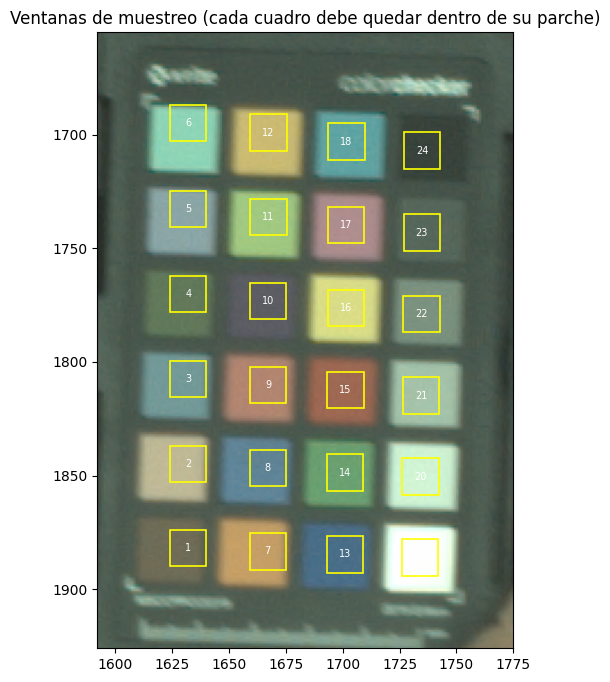

Parches excluidos por saturación: [19]
Ganancias de balance de blancos (R, G, B): [1.3018 0.6353 0.9633]
Matriz de calibración 3x3:
 [[ 1.537  -0.2589  0.0073]
 [-0.3831  1.8332 -0.8174]
 [-0.1616 -0.546   1.8134]]


,ΔE medio,ΔE máximo
Solo exposición,30.24,50.88
+ Balance de blancos,18.78,46.54
+ Matriz 3x3,2.76,5.37
Matriz 3x3 (leave-one-out),3.22,6.84


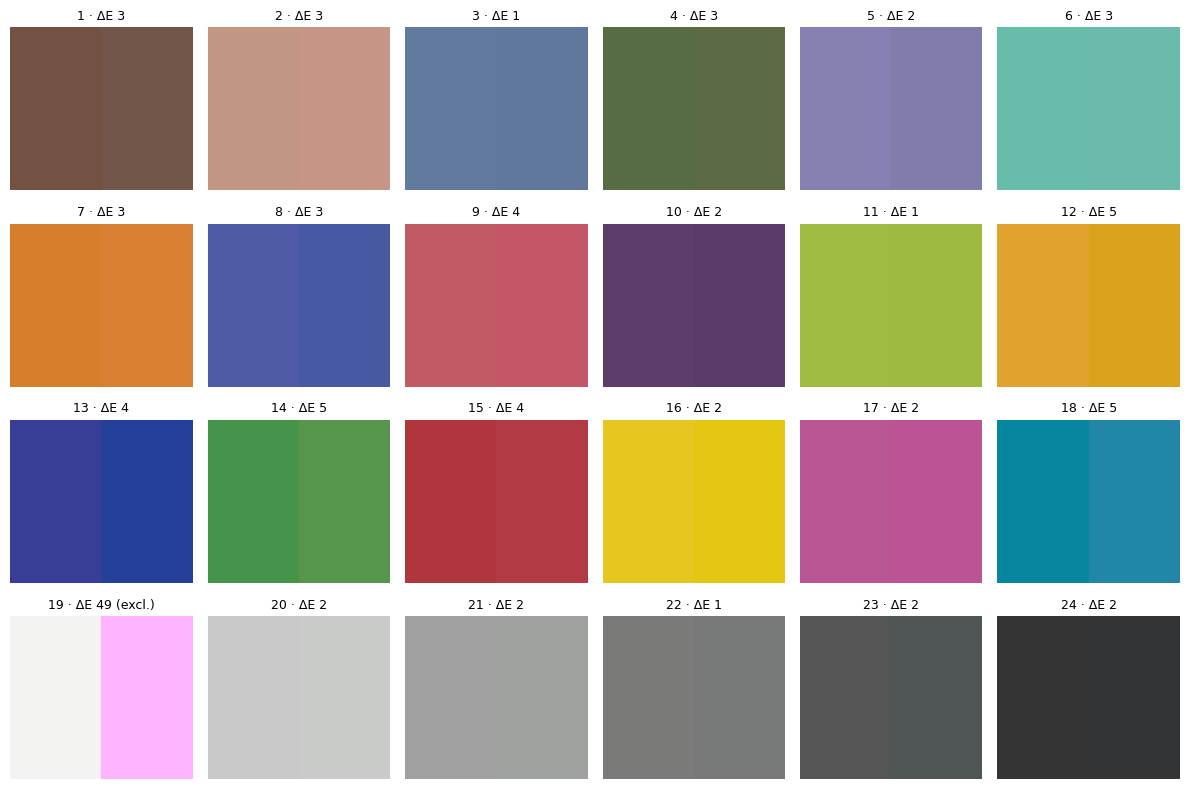

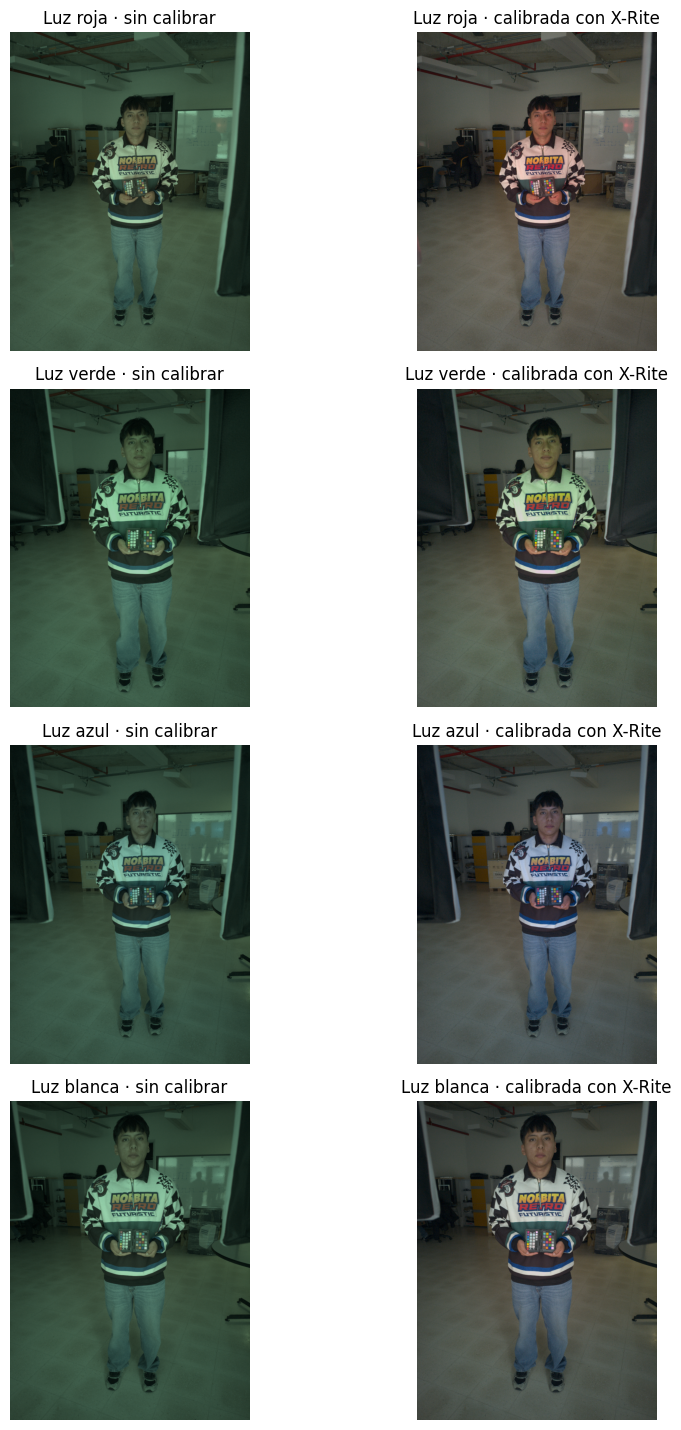

In [ ]:
# =====================================================================
# Calibración de color con el patrón X-Rite (ColorChecker Passport, panel derecho)
# Requiere la celda 9 (usa la variable `patron`).
# =====================================================================

# ---------- 1) Parámetros ----------
# Centros (x, y) en píxeles de la imagen completa, identificados por el COLOR del parche:
# P1 = marrón oscuro, P6 = verde azulado, P24 = negro, P19 = blanco
PUNTOS = {"P1": (1632, 1882), "P6": (1632, 1695), "P24": (1735, 1707), "P19": (1734, 1886)}
RADIO = 8            # mitad del lado de la ventana de muestreo por parche (px)
UMBRAL_SAT = 0.95    # parche con algún canal por encima de este valor = saturado

# Valores sRGB de referencia del ColorChecker Classic (fila por fila, de arriba a la izquierda).
# Son los valores comúnmente publicados: verifícalos con los datos de tu curso o del fabricante.
REF_SRGB = np.array([
    [115, 82, 68], [194, 150, 130], [98, 122, 157], [87, 108, 67], [133, 128, 177], [103, 189, 170],
    [214, 126, 44], [80, 91, 166], [193, 90, 99], [94, 60, 108], [157, 188, 64], [224, 163, 46],
    [56, 61, 150], [70, 148, 73], [175, 54, 60], [231, 199, 31], [187, 86, 149], [8, 133, 161],
    [243, 243, 242], [200, 200, 200], [160, 160, 160], [122, 122, 121], [85, 85, 85], [52, 52, 52],
], dtype=np.float64) / 255

# ---------- 2) Funciones de color ----------
def srgb_a_lineal(c):
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def lineal_a_srgb(c):
    c = np.clip(c, 0, 1)
    return np.where(c <= 0.0031308, 12.92 * c, 1.055 * c ** (1 / 2.4) - 0.055)

def srgb_a_lab(srgb):
    lin = srgb_a_lineal(srgb)
    M_xyz = np.array([[0.4124564, 0.3575761, 0.1804375],
                      [0.2126729, 0.7151522, 0.0721750],
                      [0.0193339, 0.1191920, 0.9503041]])
    t = (lin @ M_xyz.T) / np.array([0.95047, 1.0, 1.08883])      # normaliza por el blanco D65
    f = np.where(t > (6 / 29) ** 3, np.cbrt(t), t / (3 * (6 / 29) ** 2) + 4 / 29)
    return np.stack([116 * f[:, 1] - 16, 500 * (f[:, 0] - f[:, 1]), 200 * (f[:, 1] - f[:, 2])], axis=1)

def delta_e(lineal, ref_srgb=REF_SRGB):
    # ΔE76 entre el color (lineal) y la referencia, comparados en CIELAB
    return np.linalg.norm(srgb_a_lab(lineal_a_srgb(lineal)) - srgb_a_lab(ref_srgb), axis=1)

# ---------- 3) Posición de los 24 parches (homografía) y medición ----------
src = np.float32([[0, 0], [5, 0], [5, 3], [0, 3]])                       # rejilla de 6 x 4 parches
dst = np.float32([PUNTOS["P1"], PUNTOS["P6"], PUNTOS["P24"], PUNTOS["P19"]])
H = cv2.getPerspectiveTransform(src, dst)
rejilla = np.float32([[c, r] for r in range(4) for c in range(6)]).reshape(-1, 1, 2)
centros = cv2.perspectiveTransform(rejilla, H).reshape(-1, 2)

# Mediana RGB de la ventana de cada parche, normalizada a [0, 1]
medidos = np.array([
    np.median(patron[int(y) - RADIO:int(y) + RADIO, int(x) - RADIO:int(x) + RADIO].reshape(-1, 3), axis=0)
    for x, y in centros
]) / MAXVAL

# Verificación visual: cada cuadro debe quedar dentro de su parche
XA, XB = centros[:, 0].min() - 40, centros[:, 0].max() + 40
YA, YB = centros[:, 1].min() - 40, centros[:, 1].max() + 40
recorte = patron[int(YA):int(YB), int(XA):int(XB)].astype(np.float32) / MAXVAL
recorte = np.clip(recorte / np.percentile(recorte, 99.5, axis=(0, 1)), 0, 1) ** (1 / 2.2)

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(recorte, extent=[int(XA), int(XB), int(YB), int(YA)])
for k, (x, y) in enumerate(centros):
    ax.add_patch(plt.Rectangle((x - RADIO, y - RADIO), 2 * RADIO, 2 * RADIO,
                               fill=False, edgecolor="yellow", linewidth=1.2))
    ax.text(x, y, str(k + 1), color="white", fontsize=7, ha="center", va="center")
ax.set_title("Ventanas de muestreo (cada cuadro debe quedar dentro de su parche)")
plt.show()

# ---------- 4) Exclusión de parches saturados ----------
ref_lin = srgb_a_lineal(REF_SRGB)
validos = medidos.max(axis=1) < UMBRAL_SAT
print("Parches excluidos por saturación:", [int(k) + 1 for k in np.where(~validos)[0]] or "ninguno")
neutros = [k for k in range(18, 24) if validos[k]]      # parches grises válidos (19 a 24)

# ---------- 5) Calibración en tres etapas ----------
# (a) Solo exposición: una ganancia global (canal G de los grises válidos)
g_exp = (ref_lin[neutros, 1] * medidos[neutros, 1]).sum() / (medidos[neutros, 1] ** 2).sum()
etapa0 = medidos * g_exp

# (b) Balance de blancos: una ganancia por canal con los grises válidos
g_wb = (ref_lin[neutros] * medidos[neutros]).sum(axis=0) / (medidos[neutros] ** 2).sum(axis=0)
etapa1 = medidos * g_wb

# (c) Matriz 3x3 por mínimos cuadrados con los parches válidos (etapa1 @ M ≈ referencia)
M, *_ = np.linalg.lstsq(etapa1[validos], ref_lin[validos], rcond=None)
etapa2 = etapa1 @ M

print("Ganancias de balance de blancos (R, G, B):", np.round(g_wb, 4))
print("Matriz de calibración 3x3:\n", np.round(M, 4))

# ---------- 6) Validación cruzada leave-one-out ----------
idx = np.where(validos)[0]
err_loo = []
for k in idx:
    train = [j for j in idx if j != k]
    Mk, *_ = np.linalg.lstsq(etapa1[train], ref_lin[train], rcond=None)
    err_loo.append(delta_e(etapa1[k:k + 1] @ Mk, REF_SRGB[k:k + 1])[0])

# ---------- 7) Resumen del error (solo parches válidos) ----------
errores = [delta_e(e)[validos] for e in (etapa0, etapa1, etapa2)] + [np.array(err_loo)]
resumen = pd.DataFrame({
    "ΔE medio": [e.mean() for e in errores],
    "ΔE máximo": [e.max() for e in errores],
}, index=["Solo exposición", "+ Balance de blancos", "+ Matriz 3x3", "Matriz 3x3 (leave-one-out)"])
display(resumen.round(2))

# ---------- 8) Muestras de color: izquierda = referencia, derecha = calibrado ----------
de = delta_e(etapa2)
cal_srgb = lineal_a_srgb(etapa2)
fig, axs = plt.subplots(4, 6, figsize=(12, 8))
for k, ax in enumerate(axs.ravel()):
    ax.add_patch(plt.Rectangle((0, 0), 0.5, 1, color=REF_SRGB[k]))
    ax.add_patch(plt.Rectangle((0.5, 0), 0.5, 1, color=np.clip(cal_srgb[k], 0, 1)))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.set_title(f"{k + 1} · ΔE {de[k]:.0f}" + ("" if validos[k] else " (excl.)"), fontsize=9)
plt.tight_layout()
plt.show()

# ---------- 9) Aplicar la calibración a las 4 fotos ----------
fig, axs = plt.subplots(len(ORDEN), 2, figsize=(10, 3.6 * len(ORDEN)))
for i, etiqueta in enumerate(ORDEN):
    img = IMAGENES[etiqueta][::PASO, ::PASO].astype(np.float64) / MAXVAL
    forma = img.shape
    sin_cal = lineal_a_srgb(img.reshape(-1, 3) * g_exp).reshape(forma)
    con_cal = lineal_a_srgb((img.reshape(-1, 3) * g_wb) @ M).reshape(forma)
    axs[i, 0].imshow(np.clip(sin_cal, 0, 1)); axs[i, 0].set_title(f"Luz {etiqueta} · sin calibrar")
    axs[i, 1].imshow(np.clip(con_cal, 0, 1)); axs[i, 1].set_title(f"Luz {etiqueta} · calibrada con X-Rite")
for ax in axs.ravel():
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(SALIDA, "calibracion_xrite_resultado.png"), dpi=120, bbox_inches="tight")
plt.show()

# ---------- 10) Guardar los parámetros de calibración ----------
np.savez(os.path.join(SALIDA, "calibracion_xrite.npz"), g_exp=g_exp, g_wb=g_wb, M=M)